<a href="https://colab.research.google.com/github/Cesar-moncada/Int.-Artificial-y-redes-neuronales-013/blob/main/Actividad_8_Redes_Neuronales_Convolucionales.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers


In [15]:
# Cargar MNIST
(train_data, train_labels), (test_data, test_labels) = keras.datasets.mnist.load_data()

print("Datos de entrenamiento:", train_data.shape)
print("Datos de prueba:", test_data.shape)

Datos de entrenamiento: (60000, 28, 28)
Datos de prueba: (10000, 28, 28)


In [16]:
# Normalizar (0–255 → 0–1)
train_data = train_data / 255.0
test_data = test_data / 255.0

# Ajustar dimensión (CNN requiere canal)
train_data = train_data.reshape(-1, 28, 28, 1)
test_data = test_data.reshape(-1, 28, 28, 1)

# Convertir etiquetas a formato categórico
train_labels = keras.utils.to_categorical(train_labels, 10)
test_labels = keras.utils.to_categorical(test_labels, 10)

In [17]:
model = keras.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')  # SALIDA
])

# Compilar modelo
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Entrenar
history = model.fit(
    train_data, train_labels,
    epochs=10,
    validation_split=0.1
)

Epoch 1/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 57s 33ms/step - accuracy: 0.9573 - loss: 0.1388 - val_accuracy: 0.9862 - val_loss: 0.0457
Epoch 2/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 57s 34ms/step - accuracy: 0.9857 - loss: 0.0452 - val_accuracy: 0.9893 - val_loss: 0.0388
Epoch 3/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 55s 33ms/step - accuracy: 0.9903 - loss: 0.0314 - val_accuracy: 0.9913 - val_loss: 0.0330
Epoch 4/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 55s 32ms/step - accuracy: 0.9927 - loss: 0.0225 - val_accuracy: 0.9903 - val_loss: 0.0365
Epoch 5/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 56s 33ms/step - accuracy: 0.9947 - loss: 0.0166 - val_accuracy: 0.9885 - val_loss: 0.0404
Epoch 6/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 56s 33ms/step - accuracy: 0.9957 - loss: 0.0123 - val_accuracy: 0.9907 - val_loss: 0.0393
Epoch 7/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 54s 32ms/step - accuracy: 0.9966 - loss: 0.0101 - val_accuracy: 0.9918 - val_loss: 0.0369
Epoch 8/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 57s 34ms/step - accuracy: 0.9969 -

In [18]:
test_loss, test_acc = model.evaluate(test_data, test_labels)
print("Exactitud en prueba:", test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.9868 - loss: 0.0567
Exactitud en prueba: 0.9868000149726868


313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step


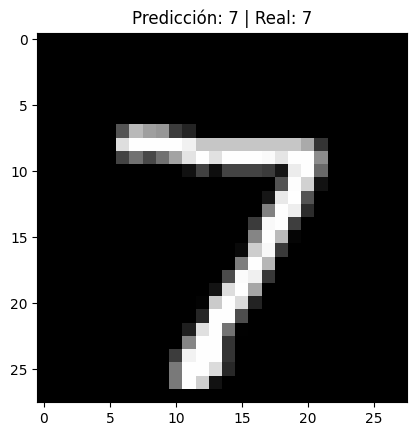

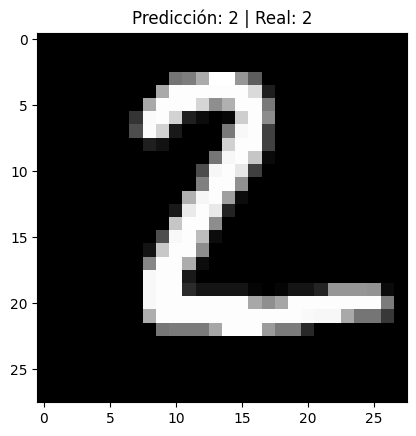

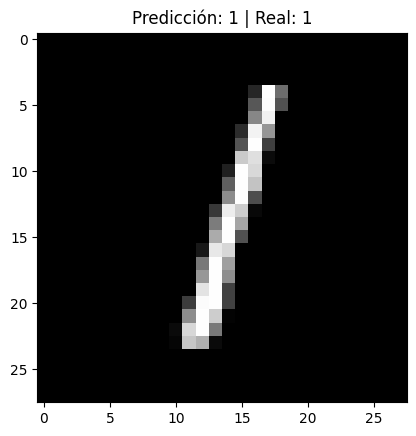

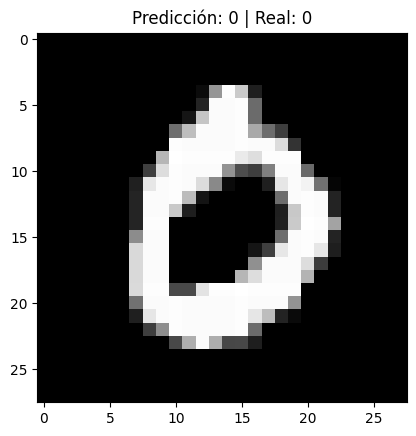

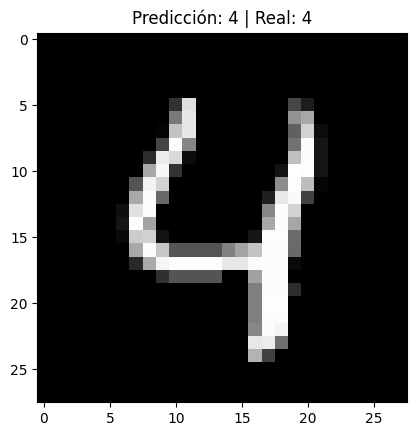

In [19]:
predictions = model.predict(test_data)

for i in range(5):
    pred = np.argmax(predictions[i])
    real = np.argmax(test_labels[i])

    plt.imshow(test_data[i].reshape(28,28), cmap='gray')
    plt.title(f"Predicción: {pred} | Real: {real}")
    plt.show()
